In [ ]:
#example with violated assumptions (non-linear data, heteroscedasticity, autocorrelated errors)

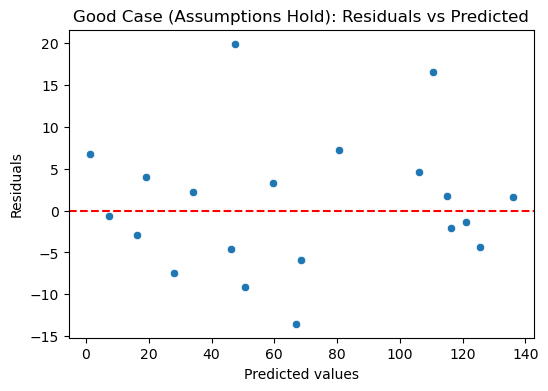

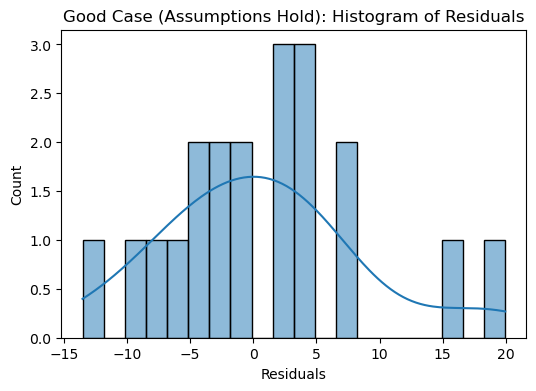

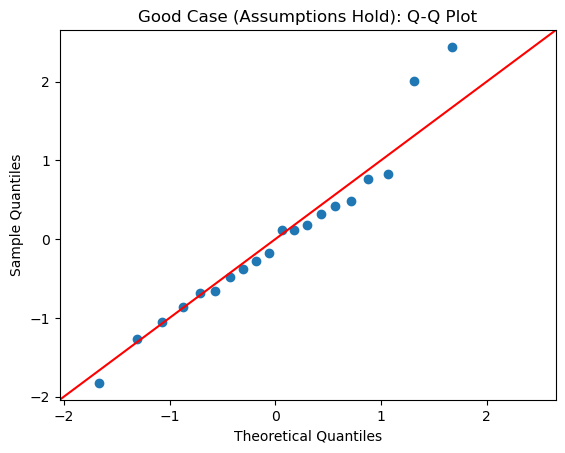

Good Case (Assumptions Hold): Durbin-Watson statistic = 1.98
------------------------------------------------------------


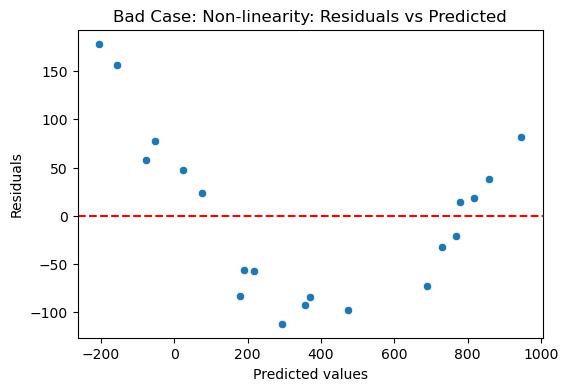

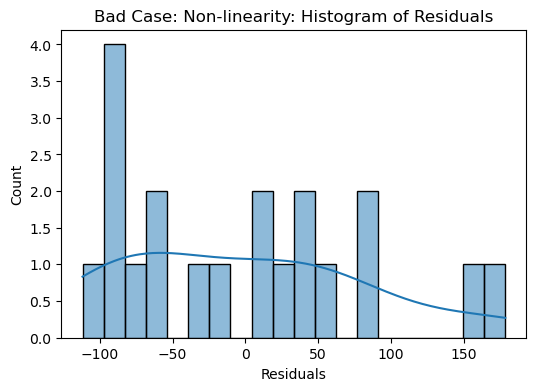

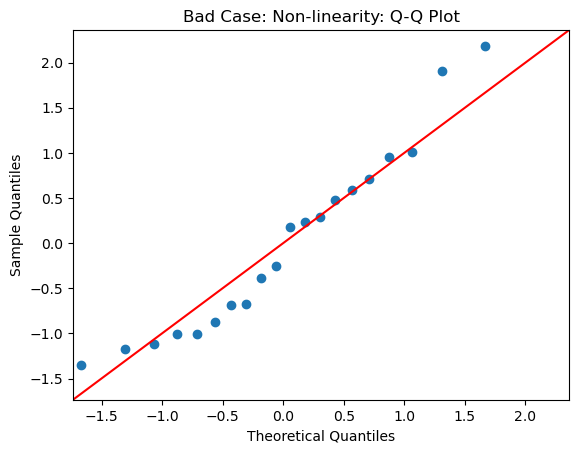

Bad Case: Non-linearity: Durbin-Watson statistic = 1.27
------------------------------------------------------------


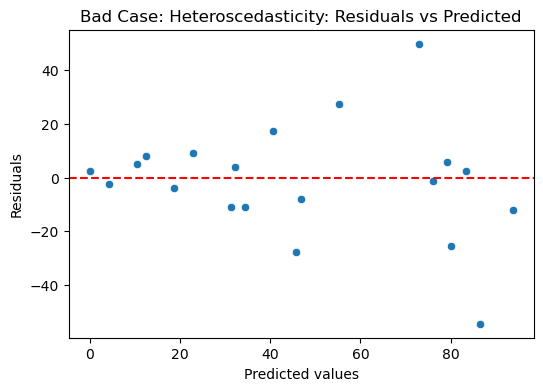

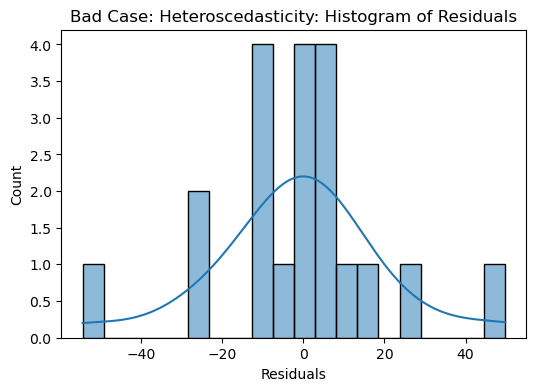

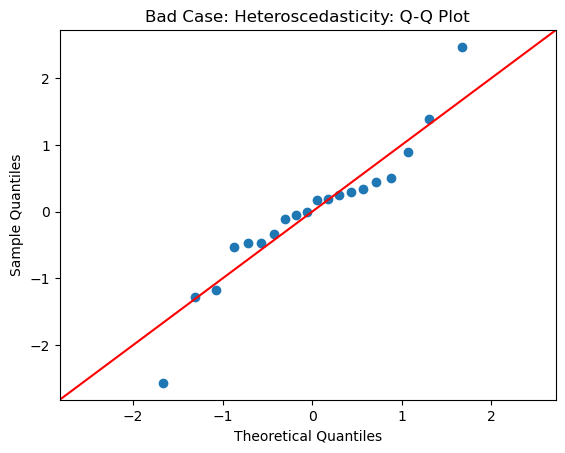

Bad Case: Heteroscedasticity: Durbin-Watson statistic = 1.81
------------------------------------------------------------


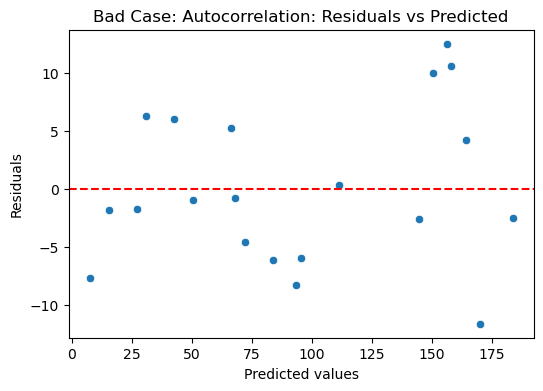

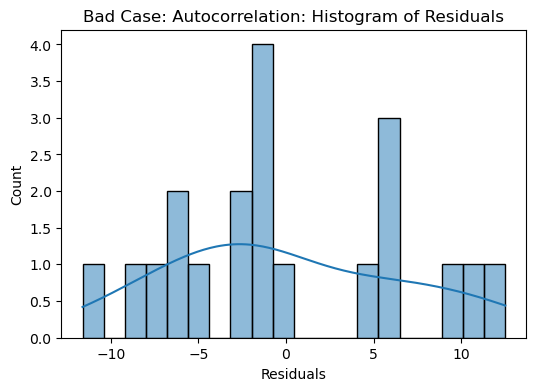

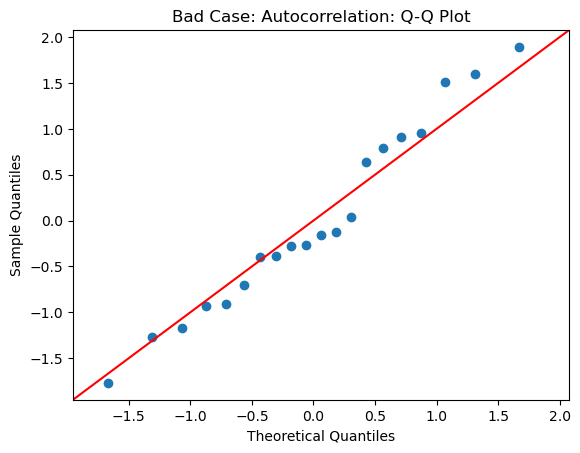

Bad Case: Autocorrelation: Durbin-Watson statistic = 1.15
------------------------------------------------------------


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# Function to plot diagnostics
def plot_diagnostics(X, y, title="Case"):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Fit Linear Regression
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    # 1. Residuals vs Predicted
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals")
    plt.title(f"{title}: Residuals vs Predicted")
    plt.show()

    # 2. Histogram of residuals
    plt.figure(figsize=(6,4))
    sns.histplot(residuals, kde=True, bins=20)
    plt.xlabel("Residuals")
    plt.title(f"{title}: Histogram of Residuals")
    plt.show()

    # 3. Q-Q Plot
    sm.qqplot(residuals, line='45', fit=True)
    plt.title(f"{title}: Q-Q Plot")
    plt.show()

    # 4. Durbin-Watson Test
    dw_stat = sm.stats.durbin_watson(residuals)
    print(f"{title}: Durbin-Watson statistic = {dw_stat:.2f}")
    print("-"*60)


# ✅ Case 1: Good Data (Linear, Homoscedastic, Independent)
np.random.seed(42)
X_good = np.linspace(1, 50, 100).reshape(-1, 1)
y_good = 3 * X_good.flatten() + np.random.normal(0, 10, 100)
plot_diagnostics(X_good, y_good, title="Good Case (Assumptions Hold)")

# ❌ Case 2: Non-linearity
X_nl = np.linspace(1, 50, 100).reshape(-1, 1)
y_nl = 0.5 * (X_nl.flatten()**2) + np.random.normal(0, 20, 100)
plot_diagnostics(X_nl, y_nl, title="Bad Case: Non-linearity")

# ❌ Case 3: Heteroscedasticity (variance increases with X)
X_het = np.linspace(1, 50, 100).reshape(-1, 1)
y_het = 2 * X_het.flatten() + np.random.normal(0, X_het.flatten(), 100)  # variance grows with X
plot_diagnostics(X_het, y_het, title="Bad Case: Heteroscedasticity")

# ❌ Case 4: Autocorrelation (time-series like errors)
X_auto = np.linspace(1, 50, 100).reshape(-1, 1)
errors = np.random.normal(0, 5, 100)
for i in range(1, 100):
    errors[i] += 0.8 * errors[i-1]  # add autocorrelation
y_auto = 4 * X_auto.flatten() + errors
plot_diagnostics(X_auto, y_auto, title="Bad Case: Autocorrelation")
